# Summary of Trigger Proposal

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
from src.constants import *
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter
import matplotlib.patches as mpatches
from affine import Affine
from rasterstats import zonal_stats
import calendar
import math

In [3]:
pd.options.display.float_format = "{:,.1f}".format

In [4]:
mam_blob_name = "ds-aa-eth-drought/exploration/Ethiopia JJAS zones.csv"
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-12-01")
season_months = [6, 7, 8, 9]
issued_months = [3, 4, 5]

In [5]:
# reading in population data
eth_adm_pop = stratus.load_csv_from_blob(
    "ds-aa-eth-drought/processed/eth_adm2_pop.csv",
    stage="dev",
    container_name="projects",
)
validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data JJAS.csv"
)
validation_csv = stratus.load_csv_from_blob(
    validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)

In [6]:
season_csv = stratus.load_csv_from_blob(
    mam_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)

era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
era5_data["valid_month"] = pd.to_datetime(era5_data["valid_date"]).dt.month
era5_data["mean"] = era5_data["mean"] * era5_data["valid_month"].map(days_in_month)

In [7]:
seas5_data["year"] = pd.to_datetime(seas5_data["valid_date"]).dt.year
seas5_data["valid_month"] = pd.to_datetime(seas5_data["valid_date"]).dt.month

seas5_data[
    (seas5_data["pcode"] == "ET0409")
    & (seas5_data["year"] == 2006)
    & (seas5_data["valid_month"].isin(season_months))
    & (pd.to_datetime(seas5_data["issued_date"]).dt.month.isin([3]))
]

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std,year,valid_month
27399,ETH,ET0409,2006-07-01,2006-03-01,4,2,3.1,3.5,0.7,7.3,571,"1,795.6",1.3,2006,7
28063,ETH,ET0409,2006-08-01,2006-03-01,5,2,3.3,3.4,0.3,8.1,571,"1,904.2",1.5,2006,8
28727,ETH,ET0409,2006-09-01,2006-03-01,6,2,2.0,2.0,0.7,5.5,571,"1,125.6",0.7,2006,9
33298,ETH,ET0409,2006-06-01,2006-03-01,3,2,1.1,1.1,0.3,3.0,571,645.1,0.5,2006,6


In [8]:
seas5_df = seas5_data.copy()
seas5_df["issued_date"] = pd.to_datetime(seas5_df["issued_date"])
seas5_df["valid_date"] = pd.to_datetime(seas5_df["valid_date"])

seas5_df["issued_month"] = seas5_df["issued_date"].dt.month
seas5_df["valid_month"] = seas5_df["valid_date"].dt.month
seas5_df["year"] = seas5_df["valid_date"].dt.year
seas5_df["mean"] = seas5_df["mean"] * seas5_df["valid_month"].map(days_in_month)

seas5_df = (
    seas5_df[
        (seas5_df["issued_month"].isin(issued_months))
        & (seas5_df["valid_month"].isin(season_months))
    ]
    .groupby(["year", "pcode", "issued_month"], as_index=False)["mean"]
    .sum()
)
seas5_df["rank"] = seas5_df.groupby(["pcode", "issued_month"])["mean"].rank(
    method="min", ascending=True
)
n_years = seas5_df["year"].nunique()
all_years = seas5_df["year"].unique()
seas5_df["return_period"] = ((n_years + 1) / seas5_df["rank"]).round(1)
df_rp = seas5_df[seas5_df["return_period"] >= 5].copy()
drought_counts = (
    df_rp.groupby(["issued_month", "year"])
    .size()
    .reset_index(name="Predictive")
    .pivot(index="year", columns="issued_month", values="Predictive")
    .fillna(0)
    .astype(int)
    .sort_index()
)

drought_counts.columns = [calendar.month_abbr[m] for m in drought_counts.columns]
drought_counts.head()

,Mar,Apr,May
year,,,
1997,74,83,83
1998,3,7,15
1999,4,0,0
2000,15,10,4
2001,28,25,9


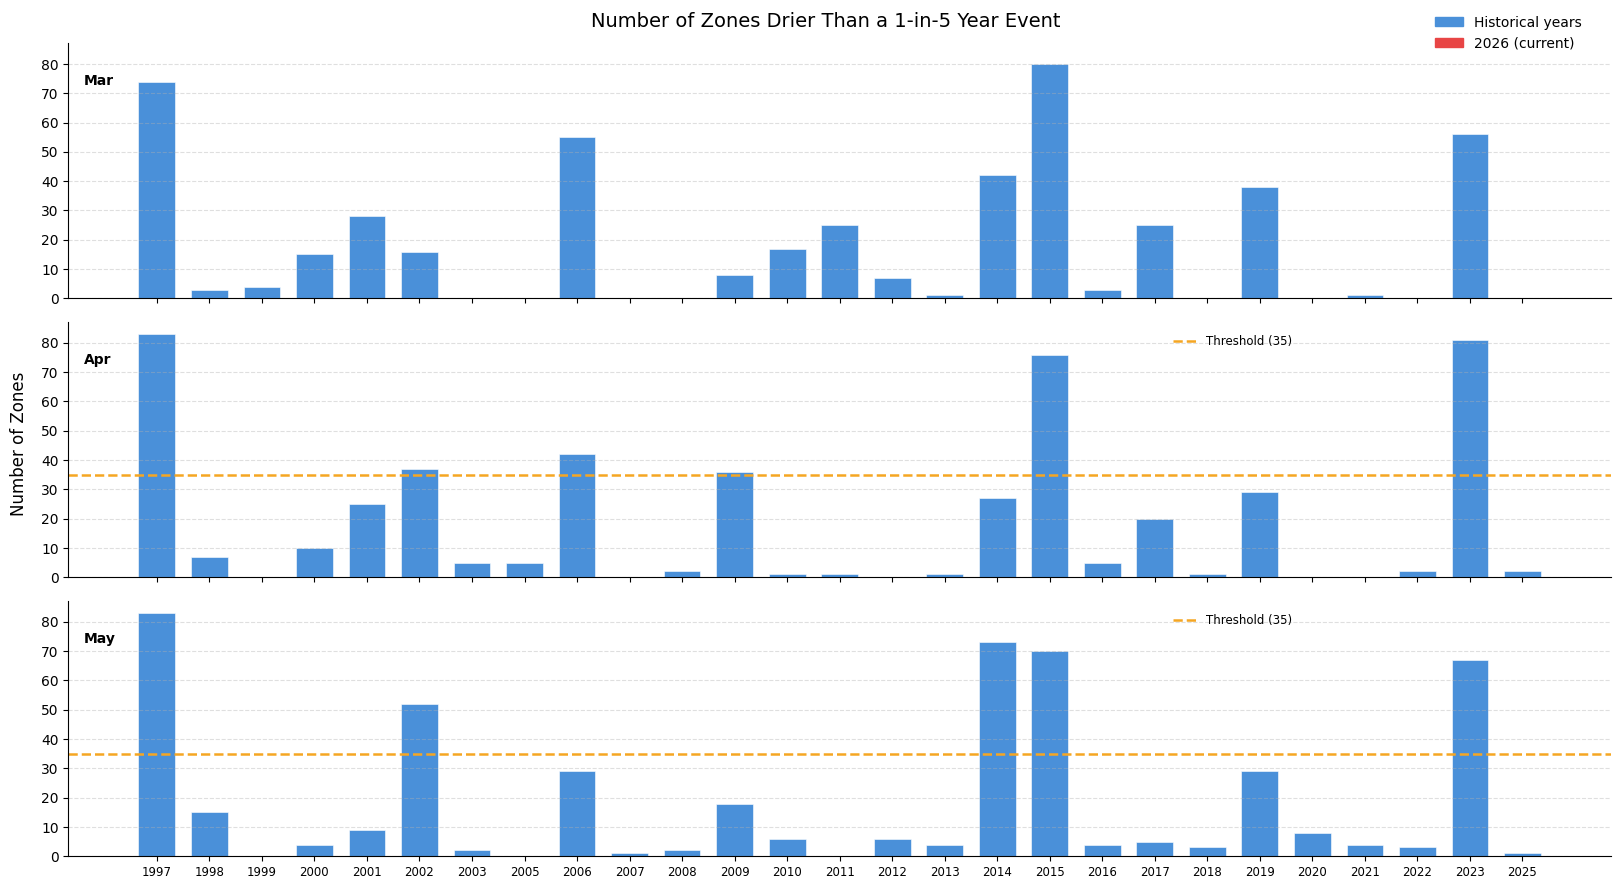

In [9]:
month_cols = drought_counts.columns.tolist()
years = drought_counts.index.astype(str).tolist()
x = np.arange(len(years))

n_months = len(month_cols)

fig, axes = plt.subplots(
    n_months, 1, figsize=(16, n_months * 3), sharey=True, sharex=True
)

for i, month in enumerate(month_cols):
    ax = axes[i]
    values = drought_counts[month].values
    colors = ["#E84545" if y == "2026" else "#4A90D9" for y in years]

    ax.bar(x, values, color=colors, edgecolor="white", linewidth=0.4, width=0.7)

    if month == "Apr" or month == "May":
        ax.axhline(
            y=35, color="#F5A623", linewidth=1.8, linestyle="--", label="Threshold (35)"
        )
        ax.legend(
            frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(0.8, 0.99)
        )

    ax.text(
        0.01,
        0.88,
        month,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left",
    )

    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(years, rotation=0, ha="center", fontsize=8.5)

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color="#4A90D9", label="Historical years"),
    plt.Rectangle((0, 0), 1, 1, color="#E84545", label="2026 (current)"),
]
fig.legend(
    handles=legend_patches,
    loc="upper right",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.98, 0.99),
)
fig.text(-0.01, 0.5, "Number of Zones", va="center", rotation="vertical", fontsize=12)
fig.suptitle("Number of Zones Drier Than a 1-in-5 Year Event", fontsize=14)

plt.tight_layout()
plt.show()

Mar 2026 SEAS5 forecast: 83 zones at ≥ 1-in-5-year RP
Apr 2026 SEAS5 forecast: 82 zones at ≥ 1-in-5-year RP
May 2026 SEAS5 forecast: 80 zones at ≥ 1-in-5-year RP


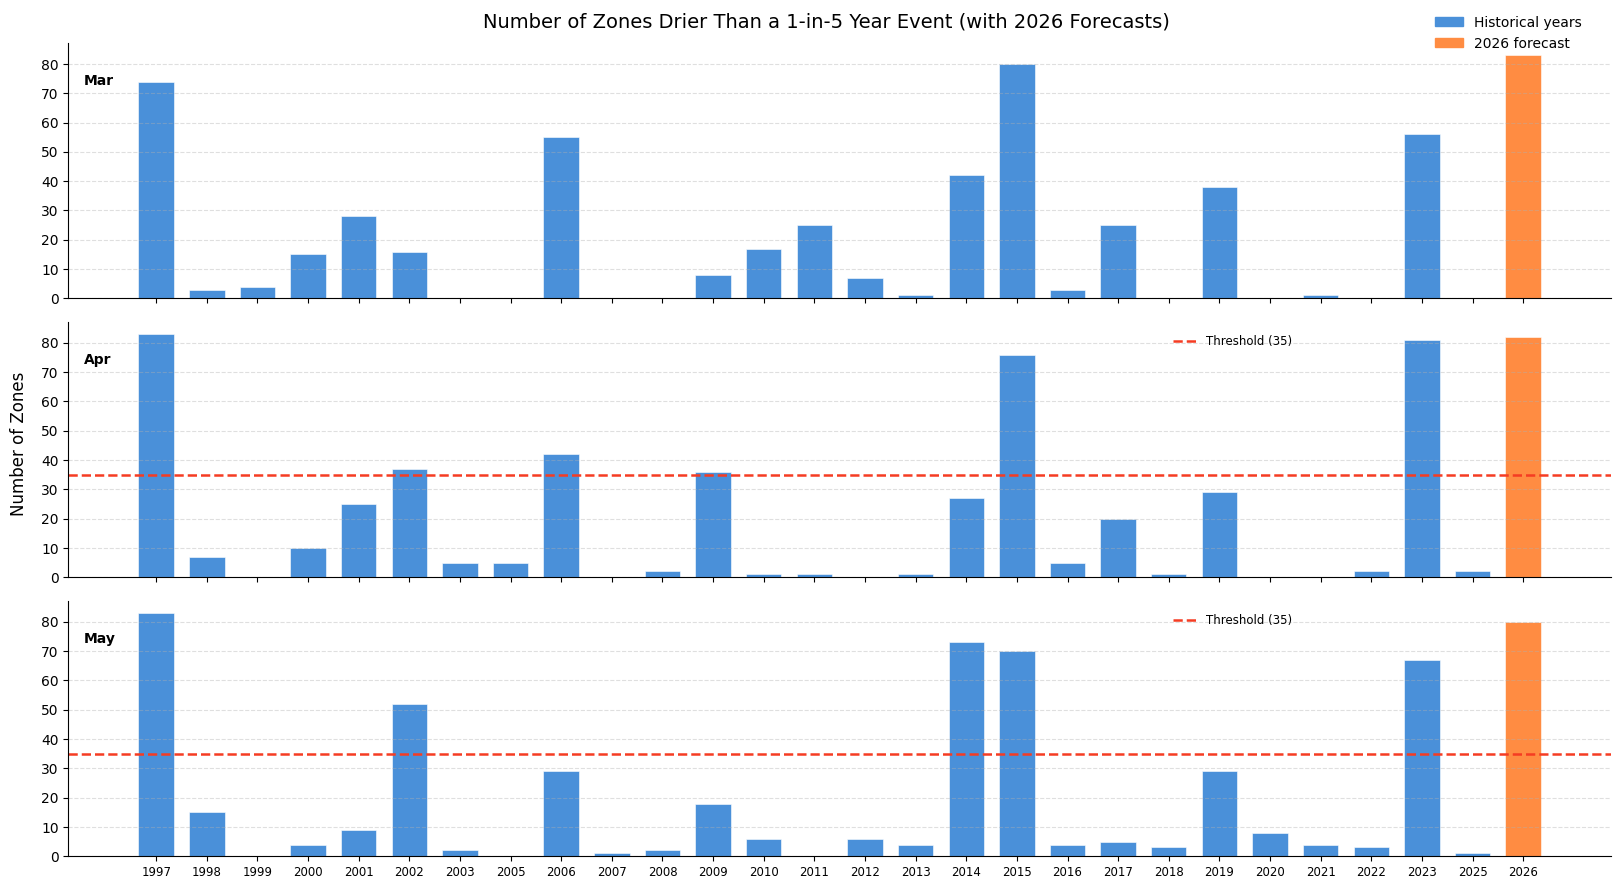

In [ ]:
# ── Mar & Apr 2026 SEAS5 forecasts – check and add to bar chart ───────────────
forecast_2026_raw = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(),
    start_date=pd.Timestamp("2026-03-01"),
    end_date=pd.Timestamp("2026-09-01"),
)

forecast_colors = {
    "Mar": "#FF8C42",
    "Apr": "#FF8C42",
    "May": "#FF8C42",
}  # purple / orange
n_zones_2026 = {"Mar": None, "Apr": None}

if not forecast_2026_raw.empty:
    forecast_2026_raw["issued_date"] = pd.to_datetime(forecast_2026_raw["issued_date"])
    forecast_2026_raw["valid_date"] = pd.to_datetime(forecast_2026_raw["valid_date"])
    forecast_2026_raw["issued_month"] = forecast_2026_raw["issued_date"].dt.month
    forecast_2026_raw["valid_month"] = forecast_2026_raw["valid_date"].dt.month
    forecast_2026_raw["year"] = forecast_2026_raw["valid_date"].dt.year
    forecast_2026_raw["mean"] = forecast_2026_raw["mean"] * forecast_2026_raw[
        "valid_month"
    ].map(days_in_month)

    for issued_month, month_abbr in [(3, "Mar"), (4, "Apr"), (5, "May")]:
        agg = (
            forecast_2026_raw[
                (forecast_2026_raw["issued_month"] == issued_month)
                & (forecast_2026_raw["valid_month"].isin(season_months))
            ]
            .groupby(["pcode", "issued_month"], as_index=False)["mean"]
            .sum()
        )

        if agg.empty:
            print(f"{month_abbr} 2026: no JJAS valid months matched.")
            continue

        agg["year"] = 2026
        hist = seas5_df[seas5_df["issued_month"] == issued_month][
            ["pcode", "issued_month", "year", "mean"]
        ].copy()
        combined = pd.concat([hist, agg], ignore_index=True)
        combined["rank"] = combined.groupby("pcode")["mean"].rank(
            method="min", ascending=True
        )
        n_total = combined["year"].nunique()
        combined["return_period"] = ((n_total + 1) / combined["rank"]).round(1)

        n_zones_2026[month_abbr] = int(
            combined[
                (combined["year"] == 2026) & (combined["return_period"] >= 5)
            ].shape[0]
        )
        print(
            f"{month_abbr} 2026 SEAS5 forecast: {n_zones_2026[month_abbr]} zones at ≥ 1-in-5-year RP"
        )
else:
    print("No Mar/Apr/May 2026 SEAS5 data available.")

# ── Re-draw bar chart including 2026 forecasts ────────────────────────────────
drought_counts_2026 = drought_counts.copy()
for month_abbr, n in n_zones_2026.items():
    if n is not None:
        drought_counts_2026.loc[2026, month_abbr] = n
drought_counts_2026 = drought_counts_2026.fillna(0).astype(int).sort_index()

month_cols_2026 = drought_counts_2026.columns.tolist()
years_2026 = drought_counts_2026.index.astype(str).tolist()
x = np.arange(len(years_2026))
n_months = len(month_cols_2026)

fig, axes = plt.subplots(
    n_months, 1, figsize=(16, n_months * 3), sharey=True, sharex=True
)

for i, month in enumerate(month_cols_2026):
    ax = axes[i]
    values = drought_counts_2026[month].values
    fc = forecast_colors.get(month)
    colors = [fc if (y == "2026" and fc is not None) else "#4A90D9" for y in years_2026]

    ax.bar(x, values, color=colors, edgecolor="white", linewidth=0.4, width=0.7)

    if month == "Apr" or month == "May":
        ax.axhline(
            y=35, color="#F53C23", linewidth=1.8, linestyle="--", label="Threshold (35)"
        )
        ax.legend(
            frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(0.8, 0.99)
        )

    ax.text(
        0.01,
        0.88,
        month,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left",
    )
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(years_2026, rotation=0, ha="center", fontsize=8.5)

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color="#4A90D9", label="Historical years"),
    plt.Rectangle((0, 0), 1, 1, color="#FF8C42", label="2026 forecast"),
]
fig.legend(
    handles=legend_patches,
    loc="upper right",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.98, 0.99),
)
fig.text(-0.01, 0.5, "Number of Zones", va="center", rotation="vertical", fontsize=12)
fig.suptitle(
    "Number of Zones Drier Than a 1-in-5 Year Event (with 2026 Forecasts)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

In [11]:
# hindcasts by region
cropland_wrsi = "ds-aa-eth-drought/exploration/leap/Final_Index_Basket_Meher.csv"
df = stratus.load_csv_from_blob(cropland_wrsi, stage="dev", container_name="projects")
# --- Extract years from first row ---
years = df.iloc[0, 2:].astype(str).str.extract(r"(\d{4})")[0].astype(int).values

# --- Drop header row and rename columns ---
data = df.iloc[1:].copy()
data.columns = ["region", "zone"] + list(years)

# --- Melt to long format ---
long_df = data.melt(
    id_vars=["region", "zone"], var_name="year", value_name="index_value"
)

# Ensure numeric
long_df["index_value"] = pd.to_numeric(long_df["index_value"], errors="coerce")

# --- Define categories ---
bins = [0, 50, 60, 80, 90, 95, 100]
labels = [
    "Complete failure (0–50)",
    "Poor (50–60)",
    "Mediocre (60–80)",
    "Average (80–90)",
    "Good (90–95)",
    "Very good (95–100)",
]

long_df["category"] = pd.cut(
    long_df["index_value"], bins=bins, labels=labels, right=True, include_lowest=True
)

# --- Count zones per year per category ---
counts = (
    long_df.groupby(["year", "category"], observed=False)
    .size()
    .reset_index(name="n_zones")
)

counts_wide = (
    counts.pivot(index="year", columns="category", values="n_zones")
    .fillna(0)
    .astype(int)
)

# Ensure correct column order
counts_wide = counts_wide[labels]
# total poor + very poor zones per year
cropland_poor_vpoor = (
    long_df[long_df["category"].isin(["Complete failure (0–50)", "Poor (50–60)"])]
    .groupby("year")
    .size()
    .reset_index(name="Cropland basket Final WRSI")
)

In [12]:
# looking at the yield reduction
season = "Meher"  # or Belg/Meher
yield_reduction_path = (
    f"ds-aa-eth-drought/exploration/leap/Yield_Reduction_Basket_{season}.csv"
)
yield_reduction = stratus.load_csv_from_blob(
    yield_reduction_path, stage="dev", container_name="projects"
)
adm2_col = yield_reduction.iloc[1:, 1].rename("adm2_name")

# keep only valid year columns
year_cols = [
    c for c in yield_reduction.columns if c.startswith("Basket_Yield_Reduction_")
]

years = [int(c.split("_")[-1]) for c in year_cols]
df = yield_reduction[["ZONENAME"] + year_cols].copy()
df = df.rename(columns={"ZONENAME": "adm2_name"})
df.columns = ["adm2_name"] + years

# ensure numeric
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
# drop col 1996
df = df.drop(columns=[1996])
# count how many adm2 have yield reduction >= 50%
yield_reduction_counts = (
    df.set_index("adm2_name")
    .ge(50)
    .sum()
    .reset_index(name="Yield Reduction ≥ 50%")
    .rename(columns={"index": "year"})
)
yield_reduction_counts.head()

,year,Yield Reduction ≥ 50%
0,2025,6
1,2024,3
2,2023,3
3,2022,11
4,2021,7


In [13]:
era_zone_year = (
    era5_data[era5_data["valid_month"].isin([6])]
    .groupby(["pcode", "year"])["mean"]
    .sum()
    .reset_index()
)

era_zone_year["rank"] = era_zone_year.groupby("pcode")["mean"].rank(
    method="min", ascending=True
)
n_years = era_zone_year["year"].nunique()
era_zone_year["return_period"] = ((n_years + 1) / era_zone_year["rank"]).round(1)

# merge population at zone level
era_zone_year = era_zone_year.merge(
    eth_adm_pop[["adm2_src", "sum"]],
    left_on="pcode",
    right_on="adm2_src",
    how="left",
)

# sum population for zones crossing 1-in-5 RP (June)
era5_zones_june_pop = (
    era_zone_year[era_zone_year["return_period"] >= 5]
    .groupby("year")  # ["sum"]
    .size()
    .reset_index(name="Affected Zones (June)")
)

In [14]:
era_zone_year = (
    era5_data[era5_data["valid_month"].isin([6, 7])]
    .groupby(["pcode", "year"])["mean"]
    .sum()
    .reset_index()
)

era_zone_year["rank"] = era_zone_year.groupby("pcode")["mean"].rank(
    method="min", ascending=True
)
n_years = era_zone_year["year"].nunique()
era_zone_year["return_period"] = ((n_years + 1) / era_zone_year["rank"]).round(1)


# sum population for zones crossing 1-in-5 RP
era5_zones_july_pop = (
    era_zone_year[era_zone_year["return_period"] >= 5]
    .groupby("year")  # ["sum"]
    .size()
    .reset_index(name="Affected Zones (July)")
)

In [15]:
era_zone_year = (
    era5_data[era5_data["valid_month"].isin([6, 7, 8, 9])]
    .groupby(["pcode", "year"])["mean"]
    .sum()
    .reset_index()
)

era_zone_year["rank"] = era_zone_year.groupby("pcode")["mean"].rank(
    method="min", ascending=True
)
n_years = era_zone_year["year"].nunique()
era_zone_year["return_period"] = ((n_years + 1) / era_zone_year["rank"]).round(1)


# sum population for zones crossing 1-in-5 RP
era5_zones_seas_pop = (
    era_zone_year[era_zone_year["return_period"] >= 5]
    .groupby("year")  # ["sum"]
    .size()
    .reset_index(name="Affected Zones (Sep)")
)

In [16]:
# vhi and asi data
vhi_asi_data = stratus.load_csv_from_blob(
    "ds-aa-eth-drought/processed/eth_asi_mam_jjas_ond.csv",
    stage="dev",
    container_name="projects",
)

In [17]:
era5_seasonal = (
    era5_data[era5_data["valid_month"].isin(season_months)]
    .groupby(["year", "pcode", "valid_month"], as_index=False)["mean"]
    .mean()
    .groupby(["year", "pcode"], as_index=False)["mean"]
    .sum()
    .groupby("year", as_index=False)["mean"]
    .mean()
    .rename(columns={"mean": "ERA5 Seasonal Rainfall"})
    .sort_values("ERA5 Seasonal Rainfall", ascending=True)
    .reset_index(drop=True)
)
era5_seasonal = era5_seasonal.merge(drought_counts, on="year", how="left")
# era5_seasonal = era5_seasonal.merge(era5_zones_june_pop, on="year", how="left")
# era5_seasonal = era5_seasonal.merge(era5_zones_july_pop, on="year", how="left")
# era5_seasonal = era5_seasonal.merge(era5_zones_seas_pop, on="year", how="left")
# era5_seasonal = era5_seasonal.merge(cropland_poor_vpoor, on="year", how="left")
# era5_seasonal = era5_seasonal.merge(
#    yield_reduction_counts, left_on="year", right_on="year", how="left"
# )
era5_seasonal = era5_seasonal.merge(
    validation_csv.drop(columns=["Season"]),
    left_on="year",
    right_on="year",
    how="left",
)

asi_cols = ["year"] + [
    c for c in vhi_asi_data.columns if c.lower().startswith("jjas_asi_wavg")
]

era5_seasonal = era5_seasonal.merge(
    vhi_asi_data[asi_cols],
    on="year",
    how="left",
)
era5_seasonal = era5_seasonal.rename(
    columns=lambda c: (
        c.lower().replace("jjas_", "").replace("_", " ").upper()
        if c.lower().startswith("jjas_")
        else c
    )
)
# drop column mar and may
era5_seasonal = era5_seasonal.drop(columns=["Mar"])
era5_seasonal = era5_seasonal.rename(
    columns={
        "year": "Year",
        "ERA5 Seasonal Rainfall": "ERA5 Seasonal Rainfall (mm)",
        "Mar": "SEAS5 Mar Forecast (Number of Zones ≥ 5 Yr RP)",
        "Apr": "SEAS5 Apr Forecast (Number of Zones ≥ 5 Yr RP)",
        "May": "SEAS5 May Forecast (Number of Zones ≥ 5 Yr RP)",
        "Affected Zones (June)": "ERA5 June (Number of Zones ≥ 5 Yr RP)",
        "Affected Zones (July)": "ERA5 July (Number of Zones ≥ 5 Yr RP)",
        "Affected Zones (Sep)": "Zones ≥ 5-Year RP (Observed)",
        "Cropland basket Final WRSI": "Cropland WRSI (Final, poor+complete failure)",
        "Yield Reduction ≥ 50%": "Zones with Yield Reduction ≥ 50%",
        "CERF Allocations": "CERF Allocations (USD)",
        "People Affected": "People Affected",
        "ASI WAVG": "ASI",
    }
)
HIGHLIGHT_RULES = {}

for col in era5_seasonal.columns:
    if col.startswith("SEAS5 "):
        HIGHLIGHT_RULES[col] = (35, "#78A2D8")

    elif col.startswith("ERA5 Ju"):
        HIGHLIGHT_RULES[col] = (45, "#DABF86")

    elif col.startswith("Zones ≥"):
        HIGHLIGHT_RULES[col] = (50, "#72D28F")

    elif col.startswith("Cropland WRSI"):
        HIGHLIGHT_RULES[col] = (18, "#72D28F")

    elif col.startswith("Zones with Yield Reduction"):
        HIGHLIGHT_RULES[col] = (12, "#72D28F")

    elif col.startswith("ASI"):
        HIGHLIGHT_RULES[col] = (35, "#D4782C")

In [18]:
styled_table = era5_seasonal.style.format(
    {
        c: ("{:,.1f}" if c.lower().startswith(("asi", "vhi")) else "{:,.0f}")
        for c in era5_seasonal.columns
        if (pd.api.types.is_numeric_dtype(era5_seasonal[c]) and c != "Year")
    },
    na_rep="",
)


for col, (thr, color) in HIGHLIGHT_RULES.items():
    styled_table = styled_table.map(
        lambda v, t=thr, c=color: (
            f"background-color: {c};" if pd.notna(v) and v >= t else ""
        ),
        subset=[col],
    )
styled_table

,Year,ERA5 Seasonal Rainfall (mm),SEAS5 Apr Forecast (Number of Zones ≥ 5 Yr RP),SEAS5 May Forecast (Number of Zones ≥ 5 Yr RP),CERF Allocations (USD),People Affected,ASI
0,2009,654,36,18,,"6,200,000",21.6
1,2023,656,81,67,"17,000,001",,5.1
2,2015,660,76,70,,"10,200,000",18.3
3,2002,666,37,52,,,23.5
4,1997,690,83,83,,,15.4
5,2021,691,0,4,,"6,800,000",3.1
6,2016,698,5,4,,,4.7
7,1999,703,0,0,,,0.0
8,2025,720,2,1,,,4.9
9,2004,720,,,,,17.2


In [19]:
trigger_mask = pd.Series(False, index=era5_seasonal.index)

for col, (thr, _) in HIGHLIGHT_RULES.items():
    if (
        col in era5_seasonal.columns
        and not col.lower().startswith("era5")
        and not col.lower().startswith(("asi", "vhi"))
    ):
        trigger_mask |= pd.to_numeric(era5_seasonal[col], errors="coerce") >= thr


styled_table = styled_table.apply(
    lambda s: ["font-weight: bold;" if trigger_mask.loc[i] else "" for i in s.index],
    axis=0,
)

styled_table

,Year,ERA5 Seasonal Rainfall (mm),SEAS5 Apr Forecast (Number of Zones ≥ 5 Yr RP),SEAS5 May Forecast (Number of Zones ≥ 5 Yr RP),CERF Allocations (USD),People Affected,ASI
0,2009,654,36,18,,"6,200,000",21.6
1,2023,656,81,67,"17,000,001",,5.1
2,2015,660,76,70,,"10,200,000",18.3
3,2002,666,37,52,,,23.5
4,1997,690,83,83,,,15.4
5,2021,691,0,4,,"6,800,000",3.1
6,2016,698,5,4,,,4.7
7,1999,703,0,0,,,0.0
8,2025,720,2,1,,,4.9
9,2004,720,,,,,17.2
